<a href="https://colab.research.google.com/github/AnnaShtyn/python_for_hw_tasks/blob/main/HW_Anna_Shtyn_11_3_%D0%A1%D1%82%D0%B0%D1%82%D0%B8%D1%81%D1%82%D0%B8%D1%87%D0%BD%D1%96_%D0%B2%D1%96%D0%B7%D1%83%D0%B0%D0%BB%D1%96%D0%B7%D0%B0%D1%86%D1%96%D1%97_%D0%B7_Seaborn.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Домашнє завдання: Статистичні візуалізації з Seaborn

## Опис завдання
У цьому домашньому завданні ви будете використовувати бібліотеку Seaborn для створення красивих статистичних візуалізацій. Seaborn має кращий стандартний стиль та спеціалізується на статистичних графіках.

**Опис колонок:**
- `datetime` - дата та час
- `season` - квартал (1-Q1, 2-Q2, 3-Q3, 4-Q4)
- `holiday` - чи є день святковим (0=ні, 1=так)
- `workingday` - чи є день робочим (0=ні, 1=так)
- `weather` - погодні умови (1=ясно, 2=туман, 3=легкий дощ, 4=сильний дощ)
- `temp` - температура в градусах Цельсія
- `atemp` - як відчувається температура
- `humidity` - вологість (%)
- `windspeed` - швидкість вітру
- `casual` - кількість випадкових користувачів
- `registered` - кількість зареєстрованих користувачів
- `count` - загальна кількість орендованих велосипедів

## Підготовка даних

---
🌱 Коментар щодо сезонності

Колонка season у датасеті представляє саме квартали року, а не метеорологічні сезони. Тому всі аналізи сезонності ви можете будувати на основі кварталів.

Водночас дані були зібрані в Індії, де поділ на сезони інший, ніж у Європі чи США. Якщо ви хочете дослідити сезонність відповідно до індійської системи сезонів, можна створити окрему колонку.

Справжні сезони в Індії:

| Сезон        | Місяці                     |
| ------------ | -------------------------- |
| Winter       | December–February (12,1,2) |
| Summer       | March–May (3,4,5)          |
| Monsoon      | June–September (6,7,8,9)   |
| Post-monsoon | October–November (10,11)   |


Тоді потрібно зробити нову колонку weather_season_india, мапнувши місяці так:

12, 1, 2 → 1 (Winter)

3, 4, 5 → 2 (Summer)

6–9 → 3 (Monsoon)

10–11 → 4 (Post-Monsoon)

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Завантаження даних
df = pd.read_csv('drive/MyDrive/yulu_bike_sharing_dataset.csv')
df['datetime'] = pd.to_datetime(df['datetime'])
df.set_index('datetime', inplace=True)

# Встановлюємо стиль seaborn
sns.set_theme(style="whitegrid")

# Додамо додаткові колонки для аналізу
df['date'] = df.index.date
df['day'] = df.index.day
df['week'] = df.index.isocalendar().week
df['weekday_num'] = df.index.weekday
df['weekday'] = df.index.day_name()
df['year'] = df.index.year
df['month'] = df.index.month
df['hour'] = df.index.hour

In [3]:
# ДОдамо колонку weather_season_india
def ind_season(val):
  if val in [12, 1, 2]:
    return 1
  elif val in [3, 4, 5]:
    return 2
  elif val in [6, 7, 8, 9]:
    return 3
  elif val in [10, 11]:
    return 4

df['weather_season_india'] = df['month'].apply(ind_season)


---

## Завдання 1: Лінійний графік з довірчими інтервалами

**Завдання:**
Побудуйте лінійний графік середньої кількості оренд помісячно з довірчими інтервалами (confidence intervals) рівними 1 стандартному відхиленню.

**УВАГА!** В лекції ми будували подібний графік, але там були дані по номеру місяця, а тут треба зобразити дані в розрізі місяць_рік.

В якості підказки вам наведений код для створення колонки, яка містить `місяць_рік`. Як її використати - вже питання до вас :)

Очікуваний результат:
![](https://drive.google.com/uc?id=1uVKqfY1VlhVMaM3wu99uVGT1f7S0Vf8S)

**Питання для інтерпретації:**
- В які місяці найбільша невизначеність в даних?

In [4]:
df['month_year'] = df.index.to_period('M')
df['month_year']  = df.month_year.astype(str)

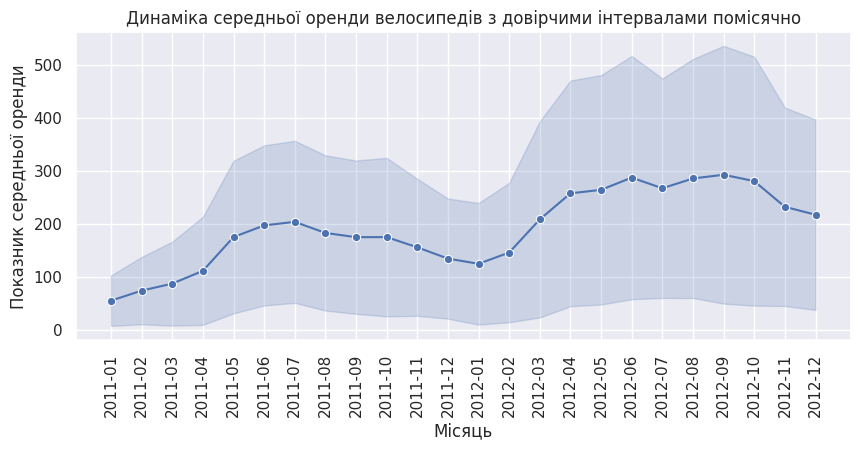

In [5]:
sns.set_theme(style= 'darkgrid')

plt.figure(figsize=(10,4))
sns.lineplot(df, x='month_year', y='count', marker='o', errorbar='sd')
plt.xticks(rotation=90)
plt.xlabel('Місяць')
plt.ylabel('Показник середньої оренди')
plt.title('Динаміка середньої оренди велосипедів з довірчими інтервалами помісячно');

# Найбільший розкид даних у вересні 2012 року.

## Завдання 2: Порівняння стилів - Pandas vs Seaborn гістограма

**Завдання:**
Побудуйте гістограму розподілу температури двома способами - з Pandas та Seaborn - та порівняйте візуальний вигляд. Задайте однакову кількість бінів в цих візуалізаціях, відмінну від стандартної. В візуалізації Seaborn додайте параметр при побудові `kde=True`.

**Функція Seaborn: `sns.histplot()`**

Можна побудувати окремо два графіки. Але для тих, хто хоче складніше - побудуйте ці 2 графіки на 1 фігурі.

**Дайте відповідь на питання:**
1. Яка візуальна різниця між Pandas та Seaborn гістограмами?
2. Що за лінія додаткова на графіку в Seaborn? Як вона називається і як ви б її описали своїми словами?

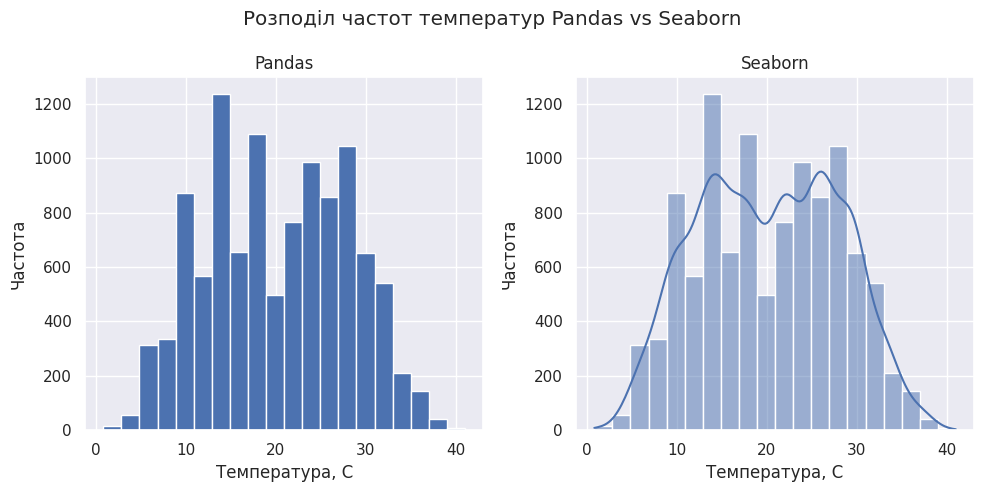

In [6]:
plt.figure(figsize=(10, 5))

plt.subplot(1, 2, 1)
df['temp'].hist(bins=20)
plt.title('Pandas')
plt.ylabel('Частота')
plt.xlabel('Температура, С')

plt.subplot(1, 2, 2)
sns.histplot(df['temp'], bins=20, kde=True)
plt.title('Seaborn')
plt.xlabel('Температура, С')
plt.ylabel('Частота')

plt.suptitle('Розподіл частот температур Pandas vs Seaborn')
plt.tight_layout();

# 1. Візуальної різниці майже немає, окрім відтінку графіків та дод.лінії на гр.Seaborn.
# 2. Як на мене, схоже на згладжену гістограму, показує тренд
# (але документація каже, що це - графік щільності розподілу(KDE), тобто описує
# ймовірність отримати значення поблизу певної точки).

## Завдання 3: Box Plot порівняння - Pandas vs Seaborn

**Завдання:**
Побудуйте box plot для кількості погодинних оренд велосипедів за погодними умовами з Pandas та Seaborn.

**Функція Seaborn: `sns.boxplot()`**

Можна побудувати окремо два графіки. Але для тих, хто хоче складніше - побудуйте ці 2 графіки на 1 фігурі.

Просунуте доповнення:
- підпишіть погодні умови їх інтерпретацією з опису даних в обох графіках

**Дайте відповідь на питання:**
- Яка візуальна різниця між Pandas та Seaborn бокс-плотами?

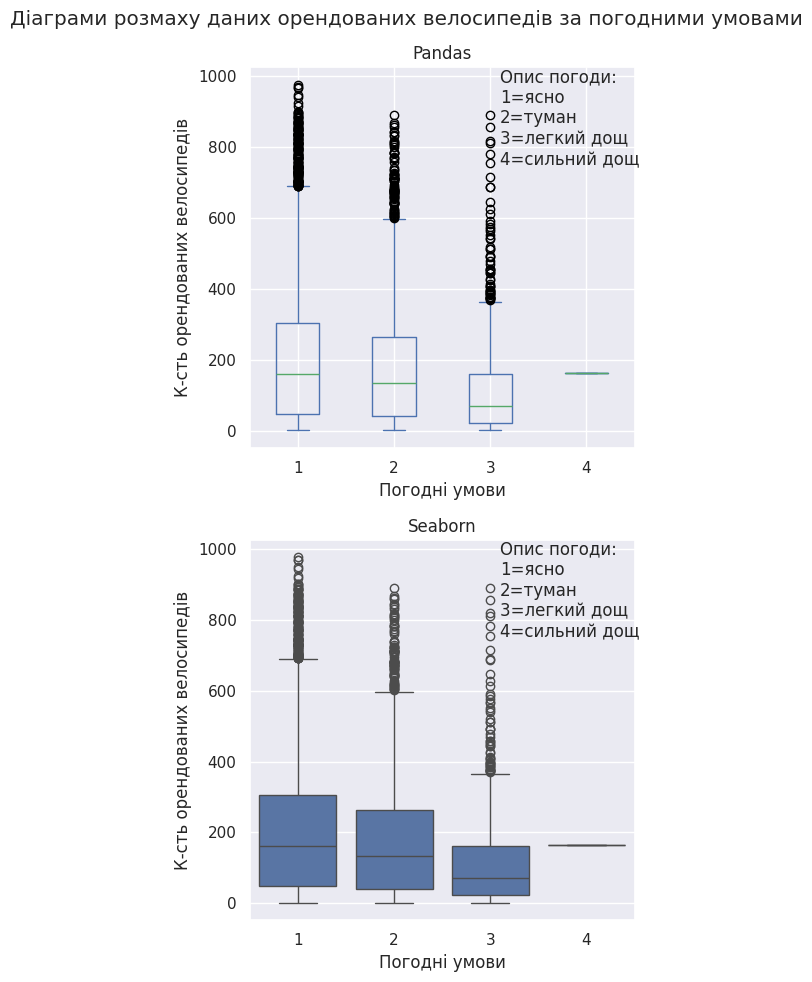

In [7]:
w_d = """Опис погоди:
1=ясно
2=туман
3=легкий дощ
4=сильний дощ"""

fig, ax = plt.subplots(2, figsize=(5,10))

df[['count', 'weather']].plot.box(by='weather', ax=ax[0])
ax[0].set_title('Pandas')
ax[0].set_xlabel('Погодні умови')
ax[0].set_ylabel('К-сть орендованих велосипедів')
ax[0].text(3.1, 750, w_d)

sns.boxplot(df, x='weather', y='count', ax= ax[1])
ax[1].set_title('Seaborn')
ax[1].set_xlabel('Погодні умови')
ax[1].set_ylabel('К-сть орендованих велосипедів')
ax[1].text(2.1, 750, w_d)

plt.suptitle('Діаграми розмаху даних орендованих велосипедів за погодними умовами')
plt.tight_layout();

# У Seaborn більше акцентується на 'ящику', він забарвлений та ширший,  яскраво
# видно квартилі та відсутня вертикальна сітка, загалом, зручніше спостерігати розкид.

<!-- - -->
## Завдання 4: Heatmap кореляційної матриці

**Завдання:**
Створіть із Seaborn кореляційну матрицю з забарвленням heatmap (колір відповідає величині значення в клітинці) числових змінних в наших даних з анотаціями значень.

**Дайте відповіді на питання по графіку:**
1. Які змінні найсильніше корелюють з загальною кількістю оренди (count)?
2. Яка кореляція між temp та atemp? Чому?
3. Які змінні мають негативну кореляцію?


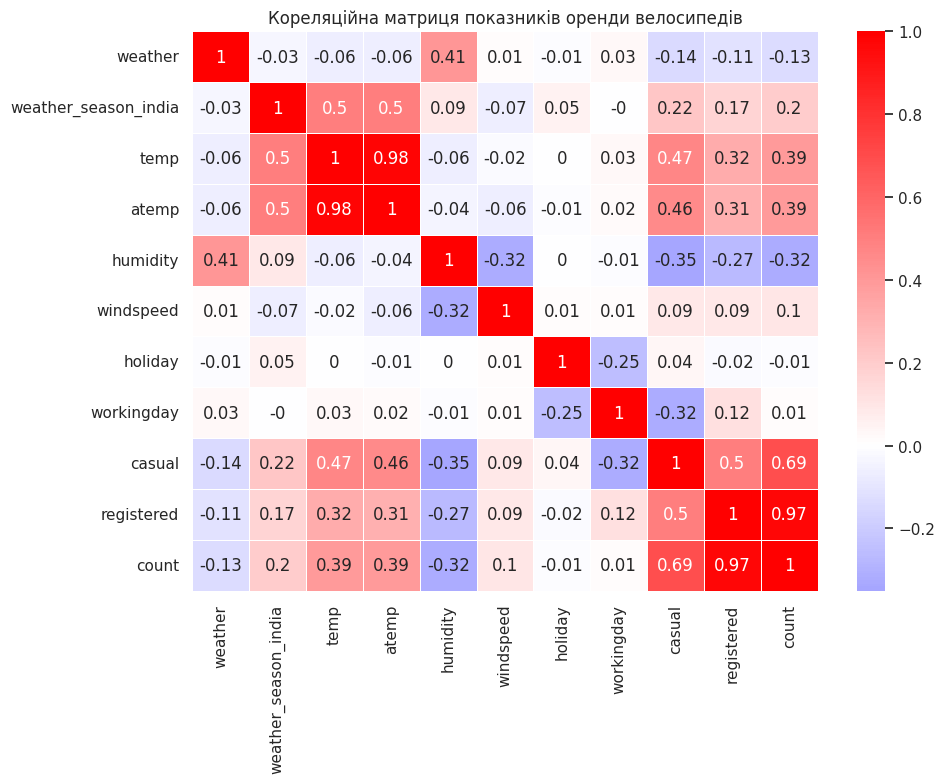

In [8]:
correlation = df[['weather', 'weather_season_india', 'temp', 'atemp', 'humidity', 'windspeed', 'holiday', 'workingday', 'casual', 'registered', 'count']].corr().round(2)

plt.figure(figsize=(10, 8))
sns.heatmap(correlation, annot=True, cmap='bwr', center=0, linewidths=0.5)
plt.title('Кореляційна матриця показників оренди велосипедів')
plt.tight_layout();

# 1. Найбільше з заг. к-стю оренди корелює з кількістю оренд зареєстровних (0.97)
#   та випадковими користувачами (0.69), що логічно, оскільки це пов'язані показники.
#   а також температура та як відчувається температура (по 0.39).
# 2. 0.98, тобто дуже сильний прямий зв'язок, оскільки як відчувається температура
#   напряму залежить від фактичної температури.
# 3. Негативну кореляцію, (тобто, обернений взаємозв'язок - коли один показник
# зростає, за силою в порядку спадання:
# -вологість та к-сть оренди випадкових користувачів(-0.35);
# -вологість та швидкість вітру(-0.32);
# -вологість та загальна к-сть оренди (-0.32);
# -робочий день та к-сть оренди випадкових користувачів (0.32);
# -вологість та к-сть оренди зареєстрованих користувачів (-0.27);
# -робочий день та вихідний день(-0.25).


## Завдання 5: Violin Plot для глибокого аналізу розподілів

**Завдання:**
Створіть violin plot для аналізу розподілу оренди за кварталами.

Дайте відповіді на питання:

**Питання для інтерпретації:**
1. Що показує "товщина" violin plot?
2. В якому кварталі найбільша варіабельність оренди?
3. Яка перевага violin plot над звичайним box plot?


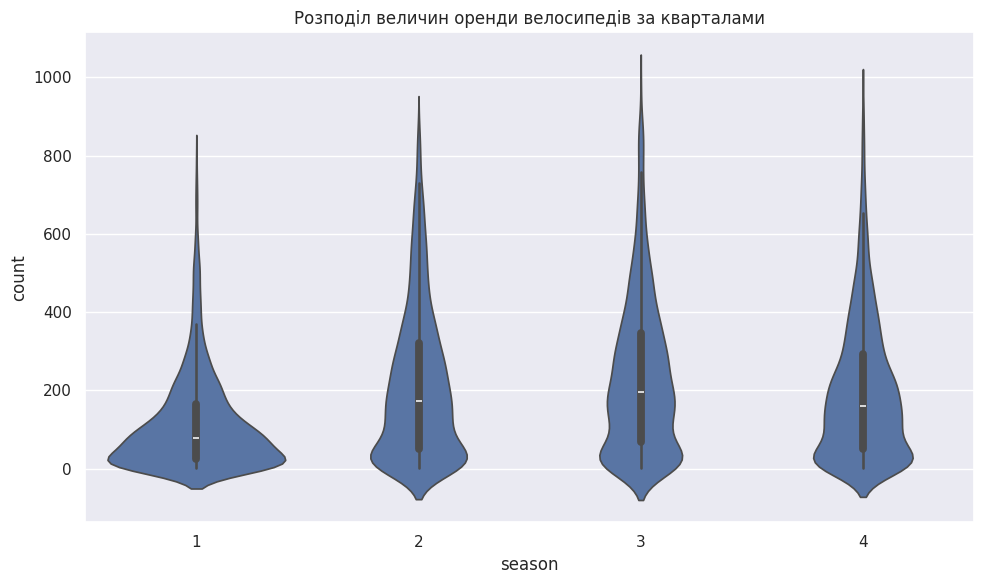

In [9]:
plt.figure(figsize=(10,6))
sns.violinplot(df, x='season', y='count')
plt.title('Розподіл величин оренди велосипедів за кварталами')
plt.tight_layout();

# 1.  "Товщина" violin plot показує оцінки щільності ядра базового розподілу, тобто
# з якою ймовірністю в нас буде певне значення к-сті орендованих велосипедів у певному кварталі.
# 2. Найбільша варіабельність у 3 кварталі, там найбільший розкид значень оренди.
# 3. Violin plot додатково показує функцію густини ймовірності, що згадано в 2п.

## Завдання 6 : Pairplot для мультиваріативного аналізу

**Завдання:**
Створіть pairplot для аналізу взаємозв'язків між ключовими змінними `'temp', 'humidity', 'windspeed', 'count'` . В якості візуальної розбивки за категоріями (параметр `hue`) додайте season (квартал).

Дайте відповіді на питання:

**Питання для інтерпретації:**
1. Між якими змінними спостерігається найсильніший лінійний зв'язок?
2. Яка характеристика найбільше відрізняється між кварталами?

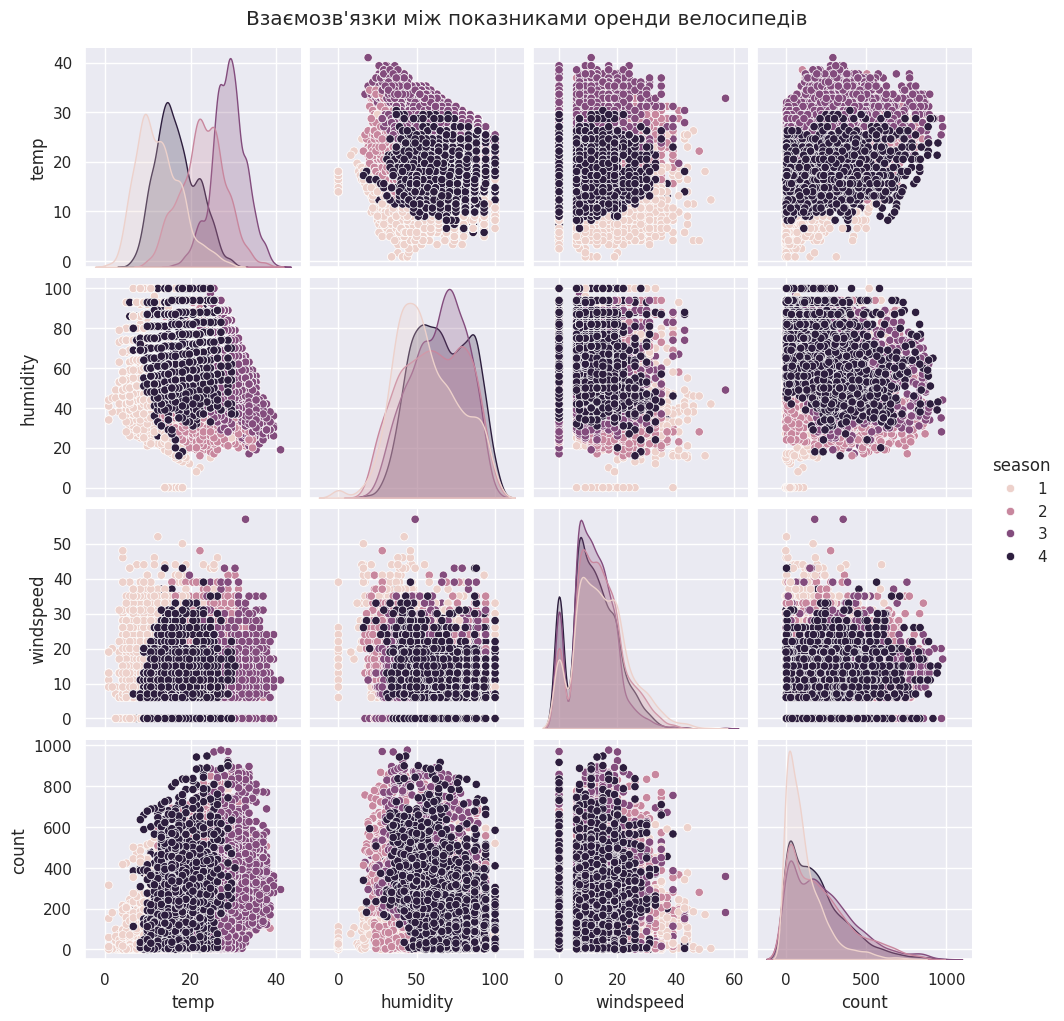

In [27]:
pairplot_df = df[['temp', 'humidity', 'windspeed', 'count', 'season']]

sns.pairplot(pairplot_df, vars=['temp', 'humidity', 'windspeed', 'count'], hue='season')
plt.suptitle("Взаємозв'язки між показниками оренди велосипедів", y=1.02);

# 1. Найбільший лінійний прямий зв'язок з заг. к-стю оренди спостерігаємо з температурою.
# 2. Мені здається, це температура та швидкість вітру.

## Завдання 7: Joint Plot для детального аналізу двох змінних

**Завдання:**
Проаналізуйте залежність між температурою та орендою за допомогою joint plot. В якості візуальної розбивки за категоріями (параметр `hue`) додайте `workingday`.

Дайте відповіді на питання:

**Питання для інтерпретації:**
1. Що показують графіки по краях?
2. Чи є різниця у поведінці користувачів у робочий і неробочий день?

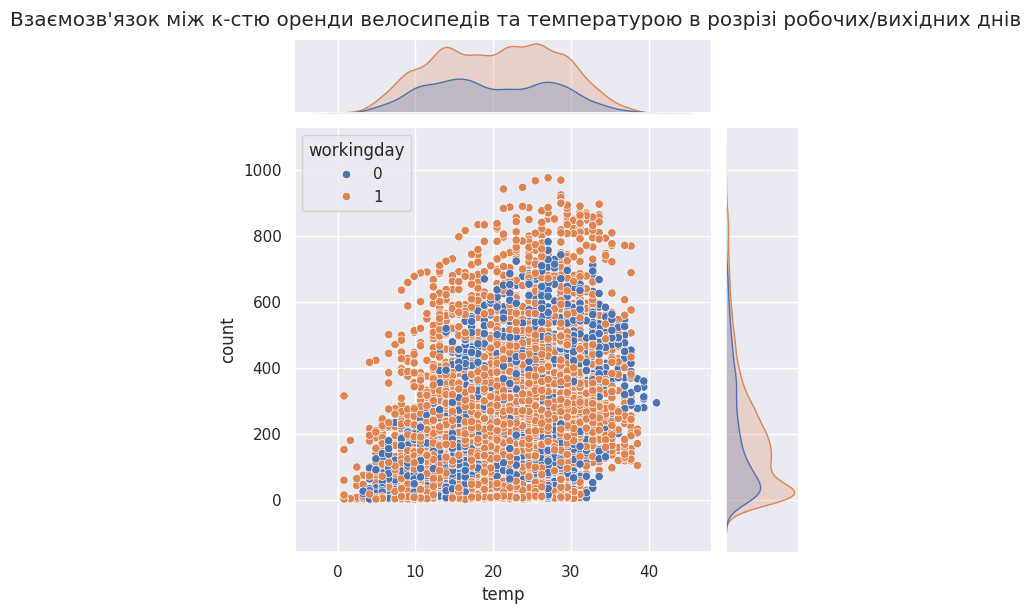

In [30]:
sns.jointplot(df, x='temp', y='count', hue='workingday')
plt.suptitle("Взаємозв'язок між к-стю оренди велосипедів та температурою в розрізі робочих/вихідних днів", y=1.02);

# 1. Графіки по краях - це вищезгадані графіки щільності розподілу (KDE) для
#   робочих/вихідних днів.
# 2. Так, у робочі дні явно вищі показники к-сті оренди, ніж у вихідні, особливо
#   за нижчої температури.